In [ ]:
!pip install langchain-openai

In [ ]:
import os
import openai

from google.colab import userdata

# Retrieve OpenAI API key from Colab secrets
Simon_GBA_479_Class = userdata.get('Simon_GBA_479_Class')


# Initialize the OpenAI client
client = openai.OpenAI(api_key=Simon_GBA_479_Class)

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving Simulate_Production.ipynb to Simulate_Production (1).ipynb
Saving Predict_Demand.ipynb to Predict_Demand (1).ipynb
Saving Calculate_Materials.ipynb to Calculate_Materials (1).ipynb
Uploaded: ['Simulate_Production (1).ipynb', 'Predict_Demand (1).ipynb', 'Calculate_Materials (1).ipynb']


In [ ]:
from langchain_core.tools import tool


# ---------- Tool 1: Demand Forecasting ----------
class PredictDemandArgs(BaseModel):
    product_id: str = Field(..., description="Product identifier, e.g. exterior_white, interior_primer, premium_gloss")
    week: int = Field(..., ge=1, le=52, description="Week of year (1-52)")
    promotion: bool = Field(False, description="Whether a promotion is active")

@tool("predict_demand", args_schema=PredictDemandArgs)
def predict_demand_tool(product_id: str, week: int, promotion: bool = False) -> dict:
    """Forecast weekly demand (gallons) with a confidence interval."""
    return predict_mod.predict_demand(product_id=product_id, week=week, promotion=promotion)


# ---------- Tool 2: Production Simulation ----------
class SimulateProductionArgs(BaseModel):
    run_size: int = Field(..., ge=1, description="Planned gallons to produce")
    defect_rate: float = Field(..., ge=0.0, le=1.0, description="Expected defect proportion (e.g., 0.02 for 2%)")
    downtime_prob: float = Field(..., ge=0.0, le=1.0, description="Probability of downtime event (0-1)")
    n_sims: int = Field(1000, ge=100, le=50000, description="Number of Monte Carlo simulations")
    target: Optional[int] = Field(None, description="Optional target gallons to evaluate probability of meeting target")

@tool("simulate_production", args_schema=SimulateProductionArgs)
def simulate_production_tool(run_size: int, defect_rate: float, downtime_prob: float,
                             n_sims: int = 1000, target: Optional[int] = None) -> dict:
    """Monte Carlo simulation of production output; returns avg, CI, and optional probability of meeting target."""
    return sim_mod.simulate_production(run_size=run_size, defect_rate=defect_rate,
                                       downtime_prob=downtime_prob, n_sims=n_sims, target=target)


# ---------- Tool 3: Materials Calculation ----------
class CalculateMaterialsArgs(BaseModel):
    order_size: int = Field(..., ge=1, description="Number of gallons ordered/produced")
    product_id: str = Field(..., description="Product identifier")

@tool("calculate_materials", args_schema=CalculateMaterialsArgs)
def calculate_materials_tool(order_size: int, product_id: str) -> dict:
    """Compute raw material requirements and estimated cost for a paint production order."""
    return mat_mod.calculate_materials(order_size=order_size, product_id=product_id)


tools = [predict_demand_tool, simulate_production_tool, calculate_materials_tool]
tools

[StructuredTool(name='predict_demand', description='Forecast weekly demand (gallons) with a confidence interval.', args_schema=<class '__main__.PredictDemandArgs'>, func=<function predict_demand_tool at 0x7e5a90003240>),
 StructuredTool(name='simulate_production', description='Monte Carlo simulation of production output; returns avg, CI, and optional probability of meeting target.', args_schema=<class '__main__.SimulateProductionArgs'>, func=<function simulate_production_tool at 0x7e5a90002200>),
 StructuredTool(name='calculate_materials', description='Compute raw material requirements and estimated cost for a paint production order.', args_schema=<class '__main__.CalculateMaterialsArgs'>, func=<function calculate_materials_tool at 0x7e5a90002980>)]

In [ ]:
def initialize_bot():
  system_message = f"""
  You are Bright Energy Paints' Operations Assistant.
Your job: answer factory operations questions using the available analytics tools.

Tools:
- predict_demand(product_id, week, promotion) -> demand forecast + confidence interval
- simulate_production(run_size, defect_rate, downtime_prob, n_sims, target) -> simulated output + CI + prob meet target
- calculate_materials(order_size, product_id) -> raw material quantities + cost

Guidelines:
- When a question requires numbers, CALL THE TOOLS (don’t guess).
- Explain results clearly and concisely for operations managers.
- If product_id is unclear, assume one of: exterior_white, interior_primer, premium_gloss.
- If a “risk” question is asked, use simulation outputs and probability of meeting target.
"""

  return system_message

In [ ]:
# ---------- Model, using LangChain ----------

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

SYSTEM = initialize_bot()

llm = ChatOpenAI(model="gpt-5-nano", temperature=0, openai_api_key=Simon_GBA_479_Class).bind_tools(tools)

In [ ]:
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode

# ---------- LangGraph ----------
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

def assistant_node(state: State):
    # Calls the model; if it wants tools, it will include tool_calls in its AI message
    ai_msg = llm.invoke(state["messages"])
    return {"messages": [ai_msg]}

tools_node = ToolNode(tools)

def route(state: State) -> str:
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else "end"

graph = StateGraph(State)
graph.add_node("assistant", assistant_node)
graph.add_node("tools", tools_node)

graph.add_edge(START, "assistant")
graph.add_conditional_edges("assistant", route, {"tools": "tools", "end": END})
graph.add_edge("tools", "assistant")  # loop back after tools

app = graph.compile()

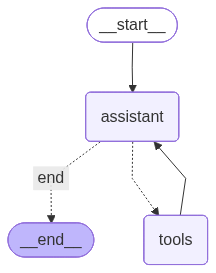

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def main():
    print("Welcome! Type 'exit' to end the chat.")

    state: State = {"messages": [SystemMessage(content=SYSTEM)]}

    # optional greeting
    state = app.invoke({"messages": state["messages"] + [HumanMessage(content="hi")]})
    print("Bot:", state["messages"][-1].content, "\n")

    while True:
        user_input = input("You: ")
        if user_input.lower() == "exit":
            return state  # includes full multi-turn transcript

        state = app.invoke({"messages": state["messages"] + [HumanMessage(content=user_input)]})

        # last message will be the assistant’s final response after any tool loop
        print("Bot:", state["messages"][-1].content, "\n")

In [ ]:
final_state = main()

Welcome! Type 'exit' to end the chat.
Bot: Hi! How can I help today?

Here are common tasks I can do for operations:

- Forecast demand
  - Specify: product_id (one of exterior_white, interior_primer, premium_gloss), week (1-52), promotion (true/false)
- Simulate production to assess risk and target
  - Specify: run_size, defect_rate, downtime_prob, n_sims, and optional target
- Calculate raw materials and cost for an order
  - Specify: order_size and product_id

If you’re not sure, I can assume exterior_white by default for a quick check. Tell me what you’d like to do (and any details like week number, run size, etc.), and I’ll run the appropriate tool(s) and report back with clear numbers and implications for operations. 

You: What’s the expected demand for exterior_white next month (week 14) if we run a promotion?”
Bot: Predicted demand for exterior_white in week 14 with promotion:
- Point forecast: 808 gallons
- Confidence interval: 749 to 867 gallons (approx. 95% CI)

Would you l